# Session 5: CNN on MNIST and YOLOv8

This notebook contains structured tasks for building a CNN on MNIST and experimenting with Ultralytics YOLOv8 (pretrained inference and a short training example).

**Instructions:**
- Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- Use `%matplotlib inline` for visualizations.
- If you need to install packages (e.g., `ultralytics`), use `%pip` in a cell.
- When using external datasets, do NOT upload them to GitHub.

### ***DO NOT UPLOAD LARGE DATASETS OR MODEL WEIGHTS TO GITHUB***
<hr>

## Task 1: Convolutional Neural Network on MNIST — Build, Train, Evaluate, Visualize
Train a simple CNN on the MNIST handwritten digits dataset. After training, generate predictions on the test set, compare them to ground truth labels, and visualize a few results.

**Why this matters:**
- MNIST is a classic entry point for image classification and CNNs.
- You will practice the full workflow: data loading, model definition, training, evaluation, and visualization.

**Steps:**
- Load MNIST with appropriate transforms (normalize).
- Define a small CNN (Conv → ReLU → Pool → FC).
- Train for a few epochs (2–3 for demo).
- Evaluate on the test set and compute accuracy.
- Visualize several test images with predicted and true labels.

**Hint:** Use `torchvision.datasets.MNIST`, `DataLoader`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.CrossEntropyLoss`.

In [4]:
# TODO: Setup environment and imports

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt

In [5]:
# TODO: Load MNIST train/test datasets and create DataLoaders
# - Apply ToTensor and Normalize transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_data = FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = FashionMNIST(root='./data', train=False,download=True, transform=transform)
# - Create train_loader and test_loader
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)


In [6]:
# TODO: Define a small CNN suitable for MNIST (1x28x28 input)
# - Use Conv2d, ReLU, MaxPool2d, Linear layers
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*5*5, 128)
        self.fc2 = nn.Linear(128, 10)
# - Return logits for 10 classes
    def forward(self, x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = Net()



In [13]:
# TODO: Set up optimizer and loss function
# - Choose Adam/SGD and CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
# TODO: Implement a short training loop (2–3 epochs)
loss_over_time = [] 
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (batch_i + 1) % 100 == 0:
                avg_loss = running_loss / 100
                loss_over_time.append(avg_loss)
                print(f"Epoch {epoch+1}, Batch {batch_i+1}, Avg. Loss: {avg_loss:.4f}")
                running_loss = 0.0
                
    # - Print loss/accuracy per epoch
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] Accuracy: {epoch_acc:.2f}%")


print("Finished Training ")
print(loss_over_time)

Epoch 1, Batch 100, Avg. Loss: 1.1399
Epoch 1, Batch 200, Avg. Loss: 0.6449
Epoch 1, Batch 300, Avg. Loss: 0.5516
Epoch 1, Batch 400, Avg. Loss: 0.5112
Epoch 1, Batch 500, Avg. Loss: 0.4857
Epoch 1, Batch 600, Avg. Loss: 0.4497
Epoch 1, Batch 700, Avg. Loss: 0.4403
Epoch 1, Batch 800, Avg. Loss: 0.4473
Epoch 1, Batch 900, Avg. Loss: 0.4045
Epoch [1/3] Accuracy: 79.91%
Epoch 2, Batch 100, Avg. Loss: 0.3955
Epoch 2, Batch 200, Avg. Loss: 0.3961
Epoch 2, Batch 300, Avg. Loss: 0.3792
Epoch 2, Batch 400, Avg. Loss: 0.3767
Epoch 2, Batch 500, Avg. Loss: 0.3714
Epoch 2, Batch 600, Avg. Loss: 0.3707
Epoch 2, Batch 700, Avg. Loss: 0.3531
Epoch 2, Batch 800, Avg. Loss: 0.3346
Epoch 2, Batch 900, Avg. Loss: 0.3409
Epoch [2/3] Accuracy: 86.70%
Epoch 3, Batch 100, Avg. Loss: 0.3375
Epoch 3, Batch 200, Avg. Loss: 0.3419
Epoch 3, Batch 300, Avg. Loss: 0.3219
Epoch 3, Batch 400, Avg. Loss: 0.3175
Epoch 3, Batch 500, Avg. Loss: 0.3295
Epoch 3, Batch 600, Avg. Loss: 0.3288
Epoch 3, Batch 700, Avg. Loss:

In [14]:
# TODO: Evaluate on the test set and compute accuracy
# - Switch model to eval mode
model.eval()
# - Accumulate correct predictions and total
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)                   
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0)                   
        correct += (predicted == labels).sum().item()  

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 87.63%


In [10]:
Class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

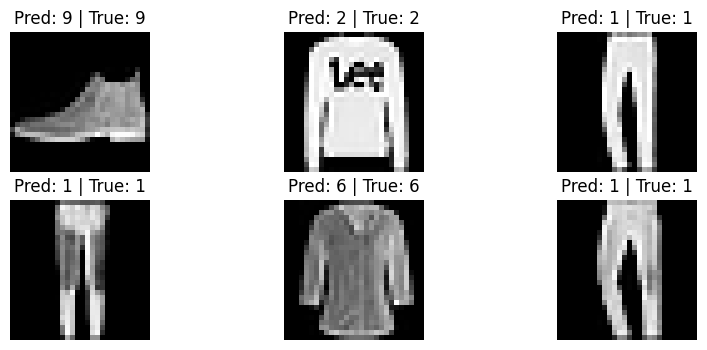

In [15]:
# TODO: Visualize a few test images with predicted and true labels
def imshow(img):
    img = img / 2 + 0.5      # unnormalize
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')
# - Sample a batch from test_loader
data_iter = iter(test_loader)
images, labels = next(data_iter)

# - Run model and plot images with 'pred vs true' titles
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    imshow(images[i].cpu())
    plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
plt.show()


## Task 2: YOLOv8 Pretrained Predictions (No Training)
Use a pretrained YOLOv8 model to run inference on any image of your choice and visualize detections.

**Why this matters:**
- Demonstrates transfer learning and using pretrained models for object detection.
- Learn how to quickly test a detector on real images.

**Steps:**
- Install `ultralytics` if not available.
- Load a YOLOv8 model (e.g., `yolov8n.pt`).
- Run predictions on an image path.
- Visualize the detections (boxes, labels, confidences).

**Hint:** Use `from ultralytics import YOLO`, `YOLO('yolov8n.pt')`, and `model.predict(source=...)`.

In [ ]:
# TODO: Install ultralytics if needed (pip)
%pip install ultralytics
# - Restart the kernel if required after installation

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2


image 1/1 /Users/salmafarida/SkyXperts-Vision-Course/tasks/sample2.jpg: 448x640 1 dog, 301.4ms
Speed: 5.7ms preprocess, 301.4ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)


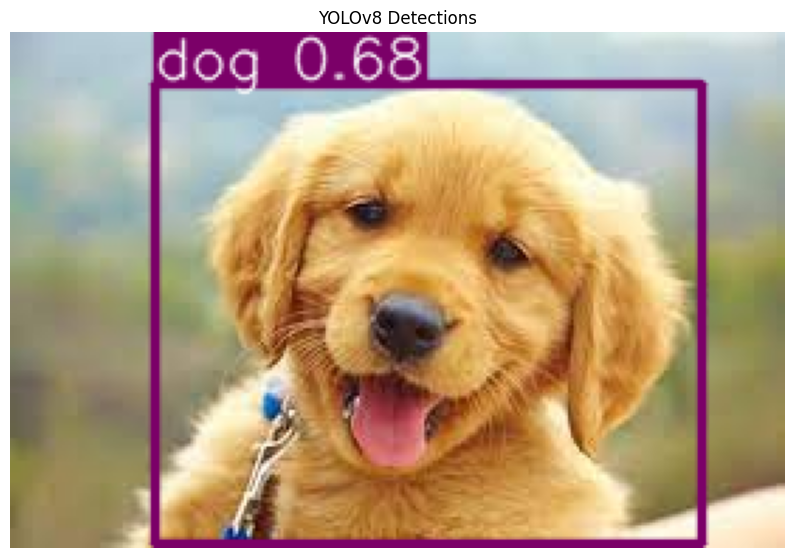

In [3]:
# TODO: Load a pretrained YOLOv8 model and run predictions on an image
model = YOLO('yolov8n.pt')
image_path = 'sample2.jpg'
results = model.predict(source=image_path, show=False)
# - Visualize results with matplotlib (convert BGR->RGB if using OpenCV)
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
annotated_img = results[0].plot() 
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_img)
plt.axis('off')
plt.title('YOLOv8 Detections')
plt.show()


## Task 3: YOLOv8 Training Example (Small Demo)
Choose any small dataset (e.g., from Roboflow or Kaggle) and train a YOLOv8 model for a few epochs (e.g., 3) as a demonstration. Then run predictions with the trained model.

**Why this matters:**
- Understand the end-to-end YOLO training pipeline.
- See how dataset configuration (classes, paths) connects to training code.

**Steps:**
- Prepare your dataset directory and a `data.yaml` describing train/val paths and class names.
- Train a small model (e.g., `yolov8n.pt`) for ~3 epochs.
- Run predictions on a few sample images.
- Reflect: Are the predictions what you expected? Why or why not?

**Notes:**
- Do NOT upload datasets to GitHub. Keep them locally or use a data hosting service.
- Training for 3 epochs is just for demonstration; try longer training later.
- If you can't use GPU, small images and fewer epochs help.
- If you can't use GPU, you can train your models on Kaggle or Google Colab in the future for free access to GPUs on their servers

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [4]:
# TODO: Provide path to your YOLOv8 data.yaml
# - Ensure train/val image directories and class names are correct
data_yaml = "coco128.yaml"

In [ ]:
# TODO: Train YOLOv8 for a few epochs (e.g., 3)
# - Save the path to best weights (runs/detect/train*/weights/best.pt)
model = YOLO("yolov8n.pt") 
results = model.train(
    data=data_yaml,  
    epochs=3,        
    imgsz=640,       
    verbose=True      
)
best_weights = model.ckpt_path if hasattr(model, "ckpt_path") else "runs/detect/train/weights/best.pt"
print(f"\nTraining complete. Best model saved at: {best_weights}")



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /Users/salmafarida/SkyXperts-Vision-Course/tasks/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 535.7ms
Speed: 138.0ms preprocess, 535.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


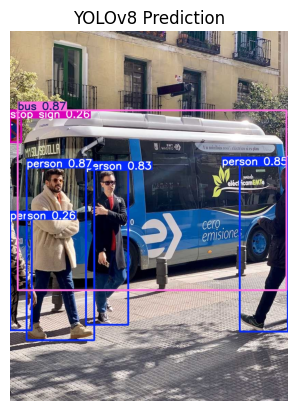

: 

In [ ]:
# TODO: Run predictions with the trained YOLO model and visualize
# - Pick one or more images and display bounding boxes/labels
trained_model = YOLO(best_weights)

image_path = "https://ultralytics.com/images/bus.jpg"
results = trained_model.predict(source=image_path, show=False)
results[0].save(filename="predicted_bus.jpg")

img = mpimg.imread("predicted_bus.jpg")
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8 Prediction")
plt.show()


### Reflection
- Are the predictions what you expected?
- If performance is weak, why? (data size/quality, epochs, augmentations, etc.)
- What would you adjust for a more serious training run?
- What other arguments can you use for the training function.